# 03 - Entrenamiento base de cierre oracional

Este notebook responde una pregunta concreta: si entrenamos **solo con sint?tico curado**, ?qu? tan bien funciona el cierre sobre la charla real `amor/desamor`?

La arquitectura base elegida para este paso es un clasificador lineal/perceptron multiclase de muy baja latencia. No es el modelo final necesariamente; es el benchmark m?nimo que tiene que ganarle a reglas simples antes de justificar un LLM chico en VM.

In [1]:
from pathlib import Path
import json
import shutil
import pandas as pd
from IPython.display import display, Markdown

from segmentacion_oraciones.src.notebook_reports import card_grid, note_box
from segmentacion_oraciones.src.llm_training import export_sft_jsonl
from segmentacion_oraciones.src.entrenar_cierre import run_synthetic_to_real_pipeline

OUT = Path('segmentacion_oraciones/outputs/notebooks/03_entrenamiento_cierre')
OUT.mkdir(parents=True, exist_ok=True)
SYNTHETIC_ZIP = Path.home() / 'Downloads' / 'synthetic_sentence_boundary_es_ar_v3_curated.zip'
AMOR_GT = Path('segmentacion_oraciones/ground_truth/charla_amor_desamor.json')
TRAIN_OUT = OUT / 'synthetic_train_amor_test'

assert SYNTHETIC_ZIP.exists(), f'No encontre el ZIP sintetico: {SYNTHETIC_ZIP}'
assert AMOR_GT.exists(), f'No encontre el ground truth de amor: {AMOR_GT}'

display(card_grid([
    ('synthetic zip', 'OK', SYNTHETIC_ZIP.name),
    ('test real', 'amor', AMOR_GT.name),
    ('entorno local', 'CPU', 'sin fine-tune pesado local'),
]))

## Contrato del dato

Entrada al modelo de cierre: `visible_context`, o sea el texto acumulado clip a clip desde el ?ltimo corte confirmado.

Salida esperada: una acci?n causal por clip.

- `wait`: todav?a no cierres oraci?n.
- `commit`: cerr? la oraci?n visible hasta este clip.
- `low_confidence`: caso dudoso; conviene esperar o mandar a fallback.

Para este experimento usamos el ZIP sint?tico como entrenamiento y `charla_amor_desamor.json` como test externo real. El ground truth de amor no se usa para entrenar.

In [2]:
sft_path = OUT / 'closure_sft_synthetic_sample.jsonl'
export_sft_jsonl([str(SYNTHETIC_ZIP)], sft_path, max_examples=2000, seed=13)

with sft_path.open(encoding='utf-8') as fh:
    rows = [json.loads(line) for line in fh if line.strip()]
first = rows[0]

display(card_grid([
    ('SFT export', sft_path.name, 'muestra para LLM chico'),
    ('ejemplos', f'{len(rows):,}', 'max_examples=2000'),
    ('synthetic true', f"{sum(1 for row in rows if row['synthetic']):,}", 'sin mezclar real'),
]))

display(Markdown('**Ejemplo de entrada/salida SFT**'))
display(first['messages'][1]['content'][:800])
display(first['messages'][2]['content'])

**Ejemplo de entrada/salida SFT**

'{"buffer_clip_count": 1, "noise_level": "bajo", "noise_tags": ["none"], "visible_context": "entonces la regularizacion busca limitar"}'

'{"action": "wait", "committed_sentence_id": null, "committed_text": "", "confidence": 1.0, "reason": "label_supervisado_de_cierre"}'

## Arquitectura definida para la base

Elegimos tres niveles, en este orden:

1. **Heur?stica conservadora**: baseline no entrenable, sirve para entender reglas obvias y riesgo de corte temprano.
2. **Lineal r?pido**: perceptron multiclase con features de texto, longitud, conectores colgantes, repetici?n, ruido y opcionalmente la decisi?n heur?stica como feature.
3. **LLM/encoder chico en VM**: siguiente etapa si el lineal no generaliza; candidato tipo encoder/distilado para clasificaci?n JSON, no generador libre.

La decisi?n para hoy: entrenar el nivel 2 con sint?tico y medir contra amor. Si no supera a la heur?stica en amor, el problema principal no es arquitectura sino gap de datos.

In [3]:
summary = run_synthetic_to_real_pipeline(
    [str(SYNTHETIC_ZIP)],
    test_input=AMOR_GT,
    output_dir=TRAIN_OUT,
    seed=13,
)

best = summary['best']
display(card_grid([
    ('train sintetico', f"{summary['train_examples']:,}", 'ejemplos'),
    ('test amor', f"{summary['test_examples']:,}", 'clips evaluados'),
    ('ganador', best['best_name'], best['selection_metric']),
    ('commit F1 amor', f"{best['commit_f1']:.3f}", 'test externo'),
    ('premature amor', f"{best['premature_commit_rate']:.3f}", 'cortes tempranos'),
    ('p95 error clips', best['boundary_error_clips']['p95_abs'], 'desvio de boundary'),
]))

## Comparaci?n de candidatos

La tabla de abajo separa validaci?n sint?tica y test real. Esta separaci?n importa: un modelo puede verse excelente en sint?tico y fallar al pasar a un video real anotado.

In [4]:
candidate_rows = []
for row in summary['candidates']:
    candidate_rows.append({
        'modelo': row['name'],
        'val_sintetico_score': row['val']['selection_score'],
        'val_sintetico_commit_f1': row['val']['commit_f1'],
        'val_sintetico_premature': row['val']['premature_commit_rate'],
        'test_amor_score': row['test']['selection_score'],
        'test_amor_commit_f1': row['test']['commit_f1'],
        'test_amor_premature': row['test']['premature_commit_rate'],
        'test_amor_low_conf_recall': row['test']['low_confidence_recall'],
        'lat_p95_ms': row['test']['latency_ms']['p95'],
    })

candidates = pd.DataFrame(candidate_rows).sort_values('test_amor_score', ascending=False)

def highlight_best(series):
    if series.name == candidates.index[0]:
        return ['background-color:#e8f5e9;font-weight:700'] * len(series)
    return [''] * len(series)

display(candidates.style.apply(highlight_best, axis=1).format({
    'val_sintetico_score': '{:.4f}',
    'val_sintetico_commit_f1': '{:.4f}',
    'val_sintetico_premature': '{:.4f}',
    'test_amor_score': '{:.4f}',
    'test_amor_commit_f1': '{:.4f}',
    'test_amor_premature': '{:.4f}',
    'test_amor_low_conf_recall': '{:.4f}',
    'lat_p95_ms': '{:.4f}',
}))

,modelo,val_sintetico_score,val_sintetico_commit_f1,val_sintetico_premature,test_amor_score,test_amor_commit_f1,test_amor_premature,test_amor_low_conf_recall,lat_p95_ms
1,heuristic,0.2516,0.5292,0.7166,0.4255,0.7769,0.8553,0.0000,0.0753
5,linear_heuristic_balanced,1.0631,0.9742,0.0112,0.1230,0.3122,0.2105,0.0000,0.1525
3,linear_text_balanced,1.0411,0.9590,0.0240,0.0618,0.2303,0.1579,0.0000,0.1288
4,linear_heuristic,1.0670,0.9787,0.0000,-0.0242,0.1573,0.0921,0.0000,0.2035
2,linear_text,1.0935,0.9970,0.0016,-0.0475,0.1348,0.1184,0.0000,0.0955
0,majority,-0.1522,0.0000,0.0000,-0.1738,0.0000,0.0000,0.0000,0.0019


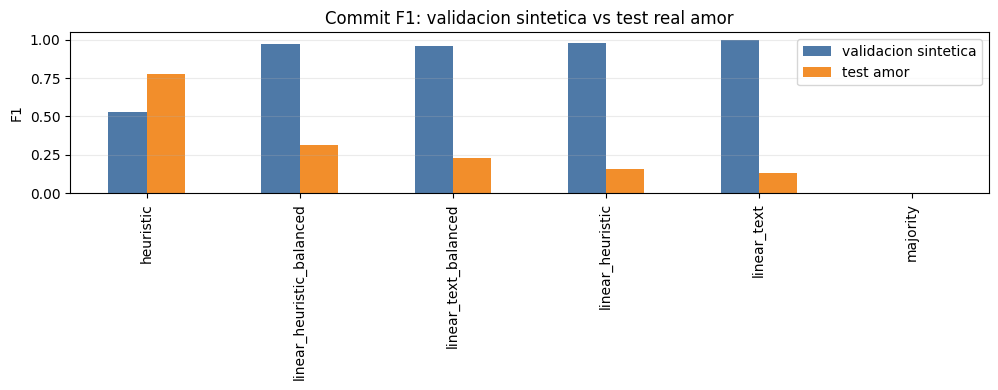

In [5]:
plot_df = candidates.set_index('modelo')[[ 'val_sintetico_commit_f1', 'test_amor_commit_f1' ]]
ax = plot_df.plot(kind='bar', figsize=(10, 4), color=['#4e79a7', '#f28e2b'])
ax.set_title('Commit F1: validacion sintetica vs test real amor')
ax.set_xlabel('')
ax.set_ylabel('F1')
ax.legend(['validacion sintetica', 'test amor'])
ax.grid(axis='y', alpha=.25)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(OUT / 'commit_f1_sintetico_vs_amor.png', dpi=160)

## Lectura del resultado

El experimento muestra un gap claro: los modelos entrenados con sint?tico aprenden muy bien la validaci?n sint?tica, pero no generalizan mejor que la heur?stica sobre `amor`.

Conclusi?n pr?ctica: por ahora conviene dejar como base productiva la heur?stica y usar el modelo lineal entrenado como artefacto experimental. El pr?ximo salto correcto no es solo ?m?s modelo?; es conseguir salida RSV real o generar sint?tico m?s parecido a RSV real, y reci?n ah? entrenar un encoder/LLM chico en VM.

In [6]:
display(note_box(
    'Decision: base actual = heuristica para amor, mas benchmark lineal entrenado con sintetico. No se declara ganador entrenable hasta tener datos RSV reales o sintetico mas parecido al ruido RSV.',
    kind='warn',
))

vm_plan = "\n".join([
    '# Plan VM cuando haya datos RSV reales o sintetico RSV-like',
    'python -m segmentacion_oraciones.src.llm_training \\',
    '  --input segmentacion_oraciones/ground_truth \\',
    '  --input synthetic_sentence_boundary_es_ar_v3_curated.zip \\',
    '  --output segmentacion_oraciones/outputs/llm_training/closure_sft.jsonl',
    '',
    '# Entrenar un encoder/LLM chico de clasificacion, no generacion libre.',
    '# Candidato inicial: modelo encoder multilingual compacto con head 3-clases.',
    '# Metricas obligatorias: commit_f1, premature_commit_rate, boundary_error_clips, latencia p95.',
])
display(Markdown('```bash\n' + vm_plan.strip() + '\n```'))

```bash
# Plan VM cuando haya datos RSV reales o sintetico RSV-like
python -m segmentacion_oraciones.src.llm_training \
  --input segmentacion_oraciones/ground_truth \
  --input synthetic_sentence_boundary_es_ar_v3_curated.zip \
  --output segmentacion_oraciones/outputs/llm_training/closure_sft.jsonl

# Entrenar un encoder/LLM chico de clasificacion, no generacion libre.
# Candidato inicial: modelo encoder multilingual compacto con head 3-clases.
# Metricas obligatorias: commit_f1, premature_commit_rate, boundary_error_clips, latencia p95.
```